# New drug tutorial (classic PK pipeline)

This notebook shows how to adapt PharmaNODE to **another drug** using the classic (non-FiLM) workflow:

1. Define a PK ODE model
2. Configure observation times, sparse encoder times, and dosing
3. Generate `virtual_cohort_{train,test}.csv` + `drug_config.json`
4. Load data for the Latent ODE (`extract_gen_pk`)
5. Smoke-test training with `run_models.py`

Run all cells from the repository root (`code/`).

## 0. Setup

In [1]:
import os
import sys
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# Run from repo root (code/)
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "docs" else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Working directory:", os.getcwd())

Working directory: /Users/benjaminmaurel/Documents/capsule/PharmaNODE/code


## 1. Study configuration

Edit `DrugStudyConfig` for your drug: observation grid, **sparse_times** (encoder inputs, replaces tacrolimus 0/1/3 h), dosing interval, residual error, etc.

In [14]:
from lib.pk_drug import DrugStudyConfig, generate_virtual_cohort, save_cohort_splits
from lib.pk_drug import extract_gen_pk, PKDataset, collate_fn_pk
from lib.classic_pk import ClassicPKModel

config = DrugStudyConfig(
    exp_id="tutorial_demo",
    observation_times=[0.0, 0.33, 0.67, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 9.0, 12.0, 24.0],
    sparse_times=[0.33, 2.0, 3.0],
    dosing_interval_h=24.0,
    n_steady_state_cycles=3,
    dose_choices=[50.0, 75.0, 100.0, 150.0],
    residual_prop_sd=0.15,
    residual_add_sd=0.05,
    unit_scale=1.0,
    auc_window=(0.0, 24.0),
)
print("Sparse encoder times (h):", config.sparse_times)
print("Full observation times after SS (h):", config.observation_times_absolute())

Sparse encoder times (h): [0.33, 2.0, 3.0]
Full observation times after SS (h): [72.0, 72.33, 72.67, 73.0, 73.5, 74.0, 75.0, 76.0, 78.0, 81.0, 84.0, 96.0]


## 2. PK model and single-patient plot

Your model must implement: `_sample_individual_parameters`, `forward`, `get_initial_state`, `state_update`, `simulate`, and `dose_mg`.

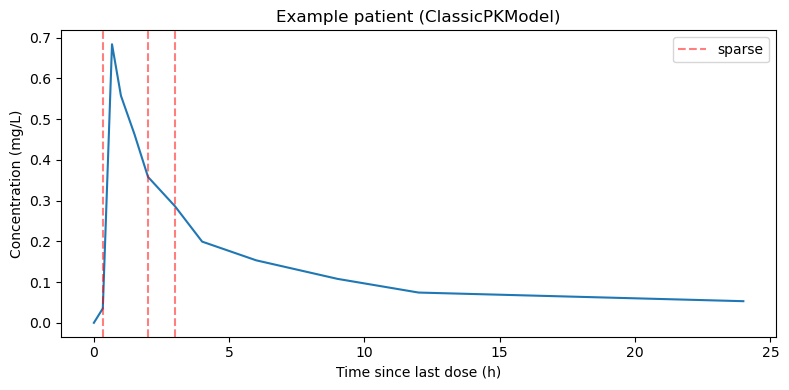

In [15]:
def pk_factory(meta):
    model = ClassicPKModel(n_compartments=3, absorption='iv', cov_data=meta)
    model.dose_mg = random.choice(config.dose_choices)
    return model

meta = {"WT": 72.0}
model = pk_factory(meta)
dosing = config.dosing_times_absolute()
times = torch.tensor(config.observation_times_absolute(), dtype=torch.float32)
conc = model.simulate(dosing, times).squeeze(-1).detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(times.numpy() - config.n_steady_state_cycles * config.dosing_interval_h, conc[:-1])
for t in config.sparse_times:
    plt.axvline(t, color="red", linestyle="--", alpha=0.5, label="sparse" if t == config.sparse_times[0] else None)
plt.xlabel("Time since last dose (h)")
plt.ylabel("Concentration (mg/L)")
plt.title("Example patient (ClassicPKModel)")
plt.legend()
plt.tight_layout()
plt.show()

### Tweaking Population Parameters

You can define custom typical values (`pop_params`) and inter-patient variabilities (`ipv`) for your PK model. The `ClassicPKModel` accepts these as dictionaries.
If not provided, it falls back to defaults for the selected number of compartments and absorption type.

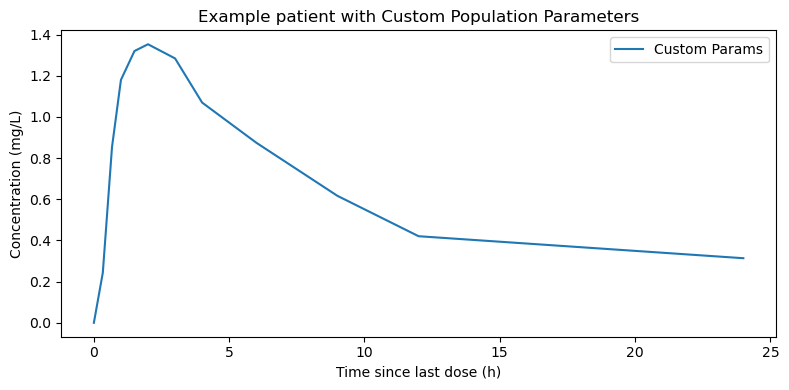

In [12]:
custom_pop_params = {"ka": 1.5, "CL": 12.0, "Vc": 50.0, "Q": 10.0, "Vp": 40.0}
custom_ipv = {"ka": 0.2, "CL": 0.2, "Vc": 0.2, "Q": 0.2, "Vp": 0.2}

model_custom = ClassicPKModel(
    n_compartments=2, 
    absorption='oral', 
    pop_params=custom_pop_params, 
    ipv=custom_ipv, 
    cov_data=meta
)

model_custom.dose_mg = 100.0
conc_custom = model_custom.simulate(dosing, times).squeeze(-1).detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(times.numpy() - config.n_steady_state_cycles * config.dosing_interval_h, conc_custom[:-1], label="Custom Params")
plt.xlabel("Time since last dose (h)")
plt.ylabel("Concentration (mg/L)")
plt.title("Example patient with Custom Population Parameters")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Generate virtual cohort CSVs

In [4]:
NUM_PATIENTS = 80
cohort_df = generate_virtual_cohort(pk_factory, config, num_patients=NUM_PATIENTS)
train_df, test_df = save_cohort_splits(cohort_df, config, test_size=0.2)
print(f"Saved to {config.results_path}")
print(f"Train patients: {train_df['ID'].nunique()}, Test patients: {test_df['ID'].nunique()}")
cohort_df.head(12)

Generating data for 80 virtual patients...
Generation complete.
Saved to ./results/tutorial_demo
Train patients: 64, Test patients: 16


,ID,PERI,AUC,mdv,ss,ST,nbr_ss,WT,TIME,DV,AMT,II
0,1,1,8.913254,1,1,0,3,79.990369,0.000000,.,150.0,24.0
1,1,1,8.913254,1,1,0,3,79.990369,-72.000000,.,150.0,24.0
2,1,1,8.913254,1,1,0,3,79.990369,-48.000000,.,150.0,24.0
3,1,1,8.913254,1,1,0,3,79.990369,-24.000000,.,150.0,24.0
4,1,1,8.913254,0,.,0,3,79.990369,0.000000,0.000001,.,.
5,1,1,8.913254,0,.,0,3,79.990369,0.330002,1.029004,.,.
6,1,1,8.913254,0,.,0,3,79.990369,0.669998,1.13131,.,.
7,1,1,8.913254,0,.,0,3,79.990369,1.000000,1.815859,.,.
8,1,1,8.913254,0,.,0,3,79.990369,1.500000,1.420352,.,.
9,1,1,8.913254,0,.,0,3,79.990369,2.000000,1.388243,.,.


## 4. Extract for NODE and inspect batches

In [5]:
data_dict, scaler = extract_gen_pk(config, plot=False)
print("Scaler max_out, boxcox lambda:", scaler)
pid = list(data_dict.keys())[0]
print("Patient", pid)
print("  sparse x_times:", data_dict[pid]["x_times"].tolist())
print("  predict times:", data_dict[pid]["times_val"].tolist())

dataset = PKDataset(data_dict)
loader = DataLoader(
    dataset,
    batch_size=min(16, len(dataset)),
    shuffle=False,
    collate_fn=lambda b: collate_fn_pk(b, config, device=torch.device("cpu")),
)
batch = next(iter(loader))
print("observed_tp:", batch["observed_tp"].tolist())
print("observed_data shape:", batch["observed_data"].shape)
print("tp_to_predict:", batch["tp_to_predict"].tolist())

Scaler max_out, boxcox lambda: [3.055544853210449, 0.3932154794708322]
Patient 1
  sparse x_times: [0.0, 2.0, 9.0]
  predict times: [0.0, 0.3300018310546875, 0.6699981689453125, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 9.0, 12.0, 24.0]
observed_tp: [0.0, 2.0, 8.0]
observed_data shape: torch.Size([16, 3, 1])
tp_to_predict: [0.0, 0.3300018310546875, 0.6699981689453125, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 9.0, 12.0, 24.0]


## 5. Smoke-test training

Training uses `--dataset PK_Tacro --experiment tutorial_demo`. When `results/tutorial_demo/drug_config.json` exists, `parse_datasets` loads your custom sparse times automatically.

In [6]:
!python run_models.py --niters 25000 -n 50 -s 40 -l 10 --dataset PK_Tacro --latent-ode \
  --noise-weight 0.01 --max-t 5. --seed 101 --experiment tutorial_demo -b 32

Sampling dataset of 50 training examples
/Users/benjaminmaurel/Documents/capsule/PharmaNODE/code/run_models.py
run_models.py --niters 25000 -n 50 -s 40 -l 10 --dataset PK_Tacro --latent-ode --noise-weight 0.01 --max-t 5. --seed 101 --experiment tutorial_demo -b 32
TensorBoard logs will be saved to: ./results/runs/tutorial_demo
----------------------------------------------------------------
Starting GMM Warm-Start Strategy
Phase 1: Pre-training Encoder on Reconstruction Loss (MSE) only
----------------------------------------------------------------
Experiment tutorial_demo
Epoch 0010 [Test seq (cond on sampled tp)] | Loss 1068.246338 | Likelihood -1202.368530 | KL fp 1.7244 | FP STD 0.4759|
KL coef: 0.0
Train loss (one batch): 731.7604370117188
Train CE loss (one batch): 0.0
Test MSE (raw): 0.2412
Test MSE (smoothed with alpha=0.99): 0.2412
New best smoothed test MSE: 0.2412. Saving best model to ./results/tutorial_demo/experiment_tutorial_demo_best.ckpt
Test MSE group_0: nan
Test MSE

In [7]:
!python test_model.py -n 50 -s 40 -l 10 --dataset PK_Tacro --latent-ode \
  --noise-weight 0.01 --max-t 5. --seed 101 --experiment tutorial_demo --load tutorial_demo --save ./results/

Sampling dataset of 50 training examples
/Users/benjaminmaurel/Documents/capsule/PharmaNODE/code/test_model.py:317: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  data = inv_boxcox(data, data_obj['max_out']['best_lambda'][0])
/Users/benjaminmaurel/Documents/capsule/PharmaNODE/code/test_model.py:318: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reconstructions = inv_boxcox(reconstructions, data_obj['max_out']['best_lambda'][0])
/Users/benjaminmaurel/Documents/capsule/PharmaNODE/code/test_model.py:323: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  auc_red = (auc_red*scaling_factor)
Processing data for 16 patients...
The indices of values with error above 15.0% are: [ 1  2  3  4  5  6  9 10 11 12 14 15] with value [ 0

## 6. Appendix: mapping from tacrolimus

| Tacrolimus (`gen_tacro.py` / `read_tacro.py`) | Generic (`DrugStudyConfig`) |
|---|---|
| `TacrolimusPK` ODE | Your `nn.Module` (e.g. `ClassicPKModel`) |
| `observation_times` + `nbr_ss` / II dosing | `observation_times` + `dosing_interval_h` + `n_steady_state_cycles` |
| Encoder times `[0, 1, 3]` h | `sparse_times` |
| `CYP`, `II` → `static` | `build_static_vector` / covariate columns |
| `extract_gen_tac` | `extract_gen_pk` |
| Monolix / MapBayEst | Not required for this tutorial |

## 6. Working with Real Data & Covariates

When you have real clinical data, you do **not** need to generate a virtual cohort. Instead, format your real dataset similarly to the generated CSVs (e.g., `virtual_cohort_train.csv`) and modify the data loading pipeline to use it.

### Formatting your CSV
Your dataset should ideally be a long-format CSV containing at minimum:
- `ID`: Patient identifier.
- `TIME`: Time of the event (observation or dose).
- `OUT`: The measured concentration (use `-1` or `NaN` if the row is just a dose event).
- `DOSE`: The amount of drug administered.
- Any covariates you wish to include (e.g., `WT` for weight, `AGE`, `SEX`).

### Defining Observation Times
In a real dataset, the time grid for the ODE solver is naturally defined by the unique times in the `TIME` column of your CSV. However, to extract specific points to feed into the Latent ODE **encoder**, you must specify the `sparse_times` argument. 
For example, if you want the encoder to only look at trough and peak concentrations taken at 0h and 2h post-dose, you would pass `sparse_times=[0.0, 2.0]` to the `extract_gen_tac` function in `lib/read_tacro.py`.

### Handling Covariates
If you have covariates like `WT` (Weight):
1. Add them as columns to your CSV.
2. Modify `lib/read_tacro.py` (inside `extract_gen_tac` or your custom extraction function) to read these columns from the pandas dataframe and append them to the `static` features list for each patient.
3. In `collate_fn_tacro`, ensure these static features are properly batched into tensors.
4. Finally, your PK Model (like `ClassicPKModel`) receives these via the `cov_data` dictionary. You can then use them to scale your parameters (e.g., allometric scaling on Clearance `CL = CL * (WT/70)**0.75`).

## 6.5 Adding Additional Covariates (e.g., Hematocrit)

In Scenario 2, you may want to generate a dataset with an additional covariate like Hematocrit (`HT`).
To do this, you can define a custom `patient_meta_fn` to sample the new covariate for each virtual patient, and add it to `config.covariate_columns` so that the data processing pipeline automatically handles it.

In [13]:
# Update config to expect an additional covariate HT
config.covariate_columns = ["WT", "HT"]
config.static_feature_names = ["dose_norm", "wt_norm", "ht_norm", "pad"]

# Define a custom patient metadata function to generate WT and HT
def my_patient_meta(config):
    return {
        "WT": random.uniform(*config.wt_range),
        "HT": random.uniform(25.0, 45.0)  # Typical hematocrit range
    }

# Generate the new cohort with the extra covariate
NUM_PATIENTS = 20
cohort_df_ht = generate_virtual_cohort(
    pk_factory, 
    config, 
    num_patients=NUM_PATIENTS,
    patient_meta_fn=my_patient_meta
)

print("Generated cohort with Hematocrit:")
display(cohort_df_ht.head())

Generating data for 20 virtual patients...
Generation complete.
Generated cohort with Hematocrit:


,ID,PERI,AUC,mdv,ss,ST,nbr_ss,WT,HT,TIME,DV,AMT,II
0,1,1,5.075046,1,1,0,3,89.366729,41.443137,0.0,.,100.0,24.0
1,1,1,5.075046,1,1,0,3,89.366729,41.443137,-72.0,.,100.0,24.0
2,1,1,5.075046,1,1,0,3,89.366729,41.443137,-48.0,.,100.0,24.0
3,1,1,5.075046,1,1,0,3,89.366729,41.443137,-24.0,.,100.0,24.0
4,1,1,5.075046,0,.,0,3,89.366729,41.443137,0.0,0.024081,.,.


## 7. Visualizing the Latent Space (`z0`)

After training the Latent ODE model, you may want to extract the latent representations (`z0`) for each patient to perform clustering or visualization (e.g., PCA, t-SNE).

In [ ]:
# Example snippet for extracting latent representations
# Ensure you have loaded your trained model first
"""
from lib.utils import get_device
device = get_device(torch.tensor(1))

# Assuming `model` is your trained Latent ODE model and `dataloader` provides your batches
model.eval()
all_z0_means = []

with torch.no_grad():
    for batch_dict in dataloader:
        # The model's encoder processes the observed data to produce the latent distribution
        z0_mean, z0_std = model.encoder_z0(
            batch_dict["observed_data"], 
            batch_dict["observed_tp"], 
            mask=batch_dict.get("observed_mask", None), 
            run_backwards=True
        )
        all_z0_means.append(z0_mean.cpu().numpy())

all_z0_means = np.concatenate(all_z0_means, axis=0).squeeze()

# For visualization, if z0 is multi-dimensional, you can use PCA:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
z0_pca = pca.fit_transform(all_z0_means)

plt.figure(figsize=(8, 6))
plt.scatter(z0_pca[:, 0], z0_pca[:, 1], alpha=0.7, c='blue')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Latent Space (z0) Visualization")
plt.show()
"""
print("Uncomment and adapt the snippet above to visualize your trained model's latent space.")